Quantum Kernel Advantage over Classical Collapse

## Reproduction and photonic translation

Paper: *Quantum Kernel Advantage over Classical Collapse in Medical
Foundation Model Embeddings*, arXiv:2604.24597.

The paper compares:

1. an untuned linear SVM with $C=1$;
2. a quantum-kernel SVM with $C=1$;
3. a C-tuned RBF SVM.

The task is binary insurance classification from frozen chest-X-ray
embeddings. The positive minority class is Private insurance, representing
30.4% of the paper's dataset.

The original MIMIC-CXR-derived embeddings require credentialed access.
This notebook therefore demonstrates selected protocol mechanics on
synthetic substitute embeddings.

Absolute metrics from this notebook are not comparable with the paper.

## Objectives

- Understand the classical and quantum kernels used in the paper.
- Reproduce linear-SVM majority-class collapse on substitute embeddings.
- Test whether the QSVM retains non-zero minority-class F1.
- Compare kernel effective ranks.
- Implement a photonic fidelity kernel with MerLin.
- Identify which conclusions do and do not transfer to the substitute data.

In [1]:
import importlib.util
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, "../..")  # repository root
sys.path.insert(0, ".")  # qsvm_medimage project

from lib.quantum_kernel import fidelity_kernel, effective_rank
from lib.data import make_synthetic_embeddings
from lib.svm_pipeline import run_one

np.set_printoptions(precision=3, suppress=True)
pd.set_option("display.max_columns", None)
MERLIN_AVAILABLE = importlib.util.find_spec("merlin") is not None

## 1. Paper protocol

The paper applies the following preprocessing pipeline:

```text
Frozen embeddings
→ StandardScaler
→ PCA to q dimensions
→ MinMaxScaler [-1, 1]
→ Kernel computation
→ SVM
```

The two main comparisons are:

| Tier | Quantum model | Classical model | Paper result |
|---|---|---|---|
| 1 | QSVM, $C=1$ | Linear SVM, $C=1$ | 18/18 minority-F1 wins |
| 2 | QSVM, $C=1$ | C-tuned RBF SVM | 7/7 minority-F1 wins |

Minority-class F1 is the primary metric because a majority-only classifier
obtains approximately 69.6% accuracy but a minority-class F1 of zero.

## 2. Quantum fidelity kernel

A classical input $\mathbf{x}\in\mathbb{R}^q$ is encoded into a quantum
state:

$$|\psi(\mathbf{x})\rangle = U(\mathbf{x})|0^q\rangle.$$

The fidelity kernel measures the squared overlap between two encoded states:

$$
K_Q(\mathbf{x},\mathbf{y})
=
\left|
\langle 0^q|
U^\dagger(\mathbf{x})U(\mathbf{y})
|0^q\rangle
\right|^2.
$$

The primary circuit described in the paper uses:

- one $R_y(x_d)$ rotation per qubit;
- CNOT ring entanglement;
- one encoding repetition.

The original repository instead implements `H`, `Rz(x)`, `Ry(x)`, a
CNOT chain, and a final `Rz(x)`. The `fidelity_kernel` used below follows
that repository implementation. It is not the different circuit described
in the paper text. The illustrative classifier run below is also
unnormalized; it is not the paper's stated trace-normalized protocol.

A valid fidelity-kernel matrix must be:

- symmetric;
- positive semidefinite;
- equal to one on the diagonal before normalization.

In [2]:
rng = np.random.default_rng(0)
X_demo = rng.uniform(-1, 1, size=(6, 4))

K_quantum = fidelity_kernel(X_demo)
eigenvalues = np.linalg.eigvalsh(K_quantum)

print("Quantum kernel")
print(K_quantum)
print()
print("Unit diagonal:", np.allclose(np.diag(K_quantum), 1.0))
print("Symmetric:", np.allclose(K_quantum, K_quantum.T))
print("Minimum eigenvalue:", eigenvalues.min())
print("Effective rank:", round(effective_rank(K_quantum), 3))

Quantum kernel
[[1.    0.065 0.038 0.179 0.337 0.009]
 [0.065 1.    0.164 0.113 0.433 0.196]
 [0.038 0.164 1.    0.267 0.12  0.027]
 [0.179 0.113 0.267 1.    0.356 0.017]
 [0.337 0.433 0.12  0.356 1.    0.046]
 [0.009 0.196 0.027 0.017 0.046 1.   ]]

Unit diagonal: True
Symmetric: True
Minimum eigenvalue: 0.4214354306470155
Effective rank: 5.429


# 3. Classical linear kernel

For PCA-compressed features $X\in\mathbb{R}^{N\times q}$, the linear
kernel is:

$$
K_L = XX^\top.
$$

Its algebraic rank is bounded by:

$$
\operatorname{rank}(K_L)\leq q.
$$

When $q\ll N$, the linear kernel has few independent directions compared
with the number of samples.

This low rank does not by itself prove classifier collapse. Collapse also
depends on class overlap, class imbalance, regularization and the decision
boundary.

In [3]:
K_linear = X_demo @ X_demo.T

print("Linear-kernel algebraic rank:", np.linalg.matrix_rank(K_linear))
print("Linear-kernel effective rank:", round(effective_rank(K_linear), 3))
print("Quantum-kernel effective rank:", round(effective_rank(K_quantum), 3))

Linear-kernel algebraic rank: 4
Linear-kernel effective rank: 3.659
Quantum-kernel effective rank: 5.429


## 4. Effective rank

Effective rank measures how broadly the eigenvalue mass is distributed:

$$
r_{\mathrm{eff}}(K)
=
\exp\left(
-\sum_i p_i\log p_i
\right),
\qquad
p_i=\frac{\lambda_i}{\sum_j\lambda_j}.
$$

A larger effective rank indicates that the kernel uses more independent
spectral directions.

It does not guarantee better classification. The alignment between those
directions and the labels also matters.

In [4]:
X, y = make_synthetic_embeddings(
    n_samples=500,
    ambient_dim=256,
    signal=0.25,
    seed=0,
)

values, counts = np.unique(y, return_counts=True)
class_distribution = pd.Series(
    counts / counts.sum(),
    index=[f"class_{value}" for value in values],
    name="proportion",
)

print("Embedding shape:", X.shape)
print(class_distribution.round(3))

Embedding shape: (500, 256)
class_0    0.696
class_1    0.304
Name: proportion, dtype: float64


## 5. Small illustrative experiment

The notebook evaluates:

- `linear_c1`: paper's Tier-1 linear baseline;
- `qsvm`: gate-based fidelity-kernel SVM;
- `rbf_rank_matched`: nonlinear classical comparison;
- `linear_balanced`: additional class-weighted diagnostic;
- `linear_tuned`: additional tuned linear diagnostic.

The rank-matched RBF model is not the paper's Tier-2 model; the paper tunes
`C` with the default RBF gamma. The last two models are additional local
diagnostics. This small run is separate from the fixed artifacts in
`results/`.

In [5]:
rows = []

for seed in range(3):
    X, y = make_synthetic_embeddings(
        n_samples=500,
        ambient_dim=256,
        signal=0.25,
        seed=seed,
    )

    rows.extend(
        run_one(
            X,
            y,
            q=8,
            seed=seed,
        )
    )

df = pd.DataFrame(rows)

order = [
    "linear_c1",
    "qsvm",
    "rbf_rank_matched",
    "linear_balanced",
    "linear_tuned",
]

summary = (
    df.groupby("method")[["f1", "auc", "recall", "eff_rank"]]
    .mean()
    .reindex(order)
)

collapse_rate = (
    df.assign(collapsed=df["f1"] < 0.05)
    .groupby("method")["collapsed"]
    .mean()
    .reindex(order)
)

summary["collapse_rate"] = collapse_rate

summary.round(3)

,f1,auc,recall,eff_rank,collapse_rate
method,,,,,
linear_c1,0.000,0.471,0.000,7.858,1.0
qsvm,0.000,0.398,0.000,29.465,1.0
rbf_rank_matched,0.000,0.405,0.000,29.475,1.0
linear_balanced,0.388,0.486,0.533,7.858,0.0
linear_tuned,0.462,0.511,1.000,7.858,0.0


## 7. Reading the metrics

### Minority-class F1

Minority-class F1 combines precision and recall for the positive minority
class:

$$
F_1=\frac{2PR}{P+R}.
$$

A classifier predicting no minority samples obtains $F_1=0$.

### ROC-AUC

ROC-AUC measures score ranking across all decision thresholds.

Two methods can have similar AUC but different F1 because F1 is evaluated at
one decision threshold.

Therefore:

- F1 detects majority-only collapse;
- AUC checks whether useful ranking information remains;
- neither metric alone establishes quantum advantage.

In [6]:
metrics = ["f1", "auc", "recall", "eff_rank", "collapse_rate"]
summary[metrics].round(3)

,f1,auc,recall,eff_rank,collapse_rate
method,,,,,
linear_c1,0.000,0.471,0.000,7.858,1.0
qsvm,0.000,0.398,0.000,29.465,1.0
rbf_rank_matched,0.000,0.405,0.000,29.475,1.0
linear_balanced,0.388,0.486,0.533,7.858,0.0
linear_tuned,0.462,0.511,1.000,7.858,0.0


## 8. Minority F1 and ROC-AUC

This figure separates two questions:

1. Does the classifier detect minority samples at its default threshold?
2. Does the classifier rank positive samples above negative samples?

In this deterministic small run, both the untuned linear SVM and QSVM
collapse to zero minority F1. Their AUC values are also below or near 0.5.

This observation is specific to the substitute experiment. It does not show
that the paper's result on the original embeddings is a threshold artifact.

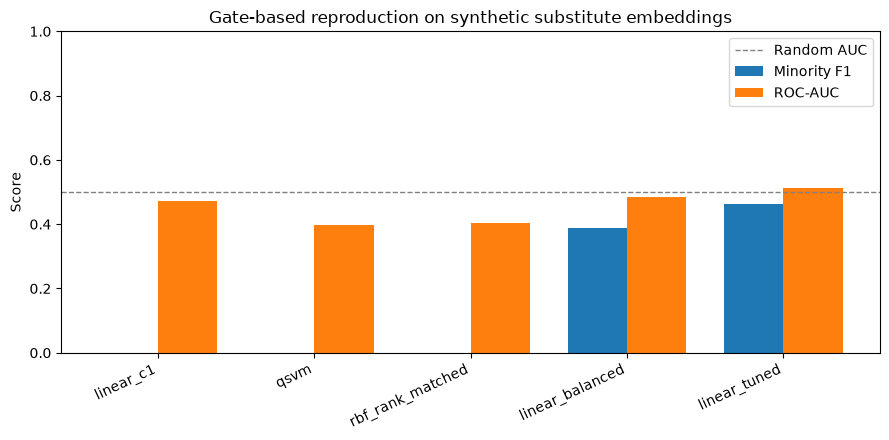

In [7]:
plot_data = summary.loc[order]
x = np.arange(len(order))
width = 0.38

fig, ax = plt.subplots(figsize=(9, 4.5))

ax.bar(
    x - width / 2,
    plot_data["f1"],
    width,
    label="Minority F1",
)

ax.bar(
    x + width / 2,
    plot_data["auc"],
    width,
    label="ROC-AUC",
)

ax.axhline(
    0.5,
    linestyle="--",
    color="gray",
    linewidth=1,
    label="Random AUC",
)

ax.set_xticks(x)
ax.set_xticklabels(order, rotation=25, ha="right")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_title("Gate-based reproduction on synthetic substitute embeddings")
ax.legend()

plt.tight_layout()
plt.show()

## 9. What is reproduced before the photonic translation?

This small substitute experiment supports the following observations:

- the untuned linear SVM can collapse to majority-only prediction;
- the QSVM also collapses in this configuration;
- the fidelity kernel has a higher effective rank, without better F1;
- class weighting can prevent linear-SVM collapse on the substitute;
- similar AUC values can coexist with different default-threshold F1 values.

The fixed Table 1 artifacts use a different synthetic dataset and report
positive unnormalized QSVM F1. This notebook output must not be substituted
for those artifact results.

The experiment cannot establish:

- the paper's absolute F1 values;
- the paper's 18/18 and 7/7 results on MIMIC-CXR embeddings;
- clinical validity;
- computational speedup;
- hardware quantum advantage.

## 10. Photonic translation

The gate-based kernel compares quantum states through fidelity.

The same principle can be implemented with a linear-optical circuit:

$$
K_{\mathrm{ph}}(\mathbf{x},\mathbf{y})
=
\left|
\langle s|
U^\dagger(\mathbf{x})U(\mathbf{y})
|s\rangle
\right|^2.
$$

The photonic feature map is:

$$
U(\mathbf{x})
=
W_2
\operatorname{diag}
\left(
e^{i\pi x_1},\ldots,e^{i\pi x_q}
\right)
W_1,
$$

where:

- $W_1$ and $W_2$ are fixed interferometers;
- each PCA feature controls one phase shifter;
- $|s\rangle$ is a two-photon input state;
- the kernel is the transition probability between encoded states.

## 11. Photonic implementation in MerLin

Configuration:

- backend: MerLin SLOS CPU simulator;
- modes: $q$;
- photons: 2;
- encoding: one phase shifter per PCA component;
- measurement: exact transition probability;
- shots: 0;
- classifier: SVM with a precomputed photonic fidelity kernel.

The objective is not to reproduce the gate circuit operation by operation.
The objective is to translate the kernel principle into a native
linear-optical feature map.

In [8]:
rows_photonic = []

if MERLIN_AVAILABLE:
 for seed in range(2):
        X, y = make_synthetic_embeddings(
            n_samples=400,
            ambient_dim=256,
            signal=0.25,
            seed=seed,
        )

        rows_photonic.extend(
            run_one(
                X,
                y,
                q=6,
                seed=seed,
                classifiers=[
                    "qsvm_photonic",
                    "qsvm",
                    "linear_c1",
                    "linear_balanced",
                ],
            )
        )

photonic_order = [
    "linear_c1",
    "qsvm",
    "qsvm_photonic",
    "linear_balanced",
]

if MERLIN_AVAILABLE:
    df_photonic = pd.DataFrame(rows_photonic)
    photonic_summary = (
        df_photonic
        .groupby("method")[["f1", "auc", "recall", "eff_rank"]]
        .mean()
        .reindex(photonic_order)
    )
    display(photonic_summary.round(3))
else:
    photonic_summary = pd.DataFrame()
    print("Photonic section skipped: optional MerLin dependency is unavailable.")

,f1,auc,recall,eff_rank
method,,,,
linear_c1,0.000,0.516,0.000,5.806
qsvm,0.000,0.521,0.000,14.858
qsvm_photonic,0.077,0.546,0.042,51.525
linear_balanced,0.294,0.528,0.375,5.806


## 12. Gate, photonic and classical comparison

When MerLin is installed, the comparison tests whether the photonic kernel
shows the same
qualitative signatures as the gate-based fidelity kernel:

- non-zero minority-class F1;
- higher effective rank than the linear kernel;
- reduced majority-only collapse.

The gate and photonic kernels use different feature maps. Similar behaviour
does not imply identical kernel matrices or identical performance.

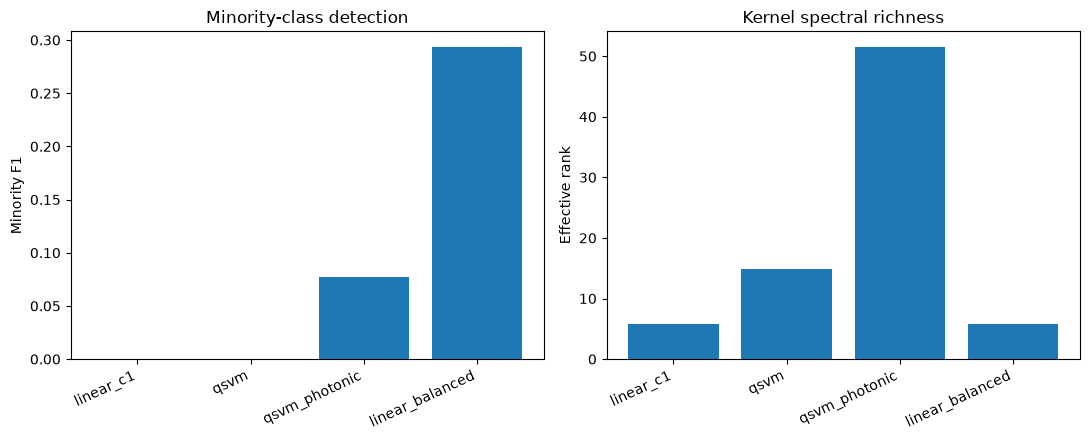

In [9]:
if photonic_summary.empty:
    print("No photonic result to plot.")
else:
 fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

 x = np.arange(len(photonic_summary))

 axes[0].bar(x, photonic_summary["f1"])
 axes[0].set_xticks(x)
 axes[0].set_xticklabels(photonic_summary.index, rotation=25, ha="right")
 axes[0].set_ylabel("Minority F1")
 axes[0].set_title("Minority-class detection")

 axes[1].bar(x, photonic_summary["eff_rank"])
 axes[1].set_xticks(x)
 axes[1].set_xticklabels(photonic_summary.index, rotation=25, ha="right")
 axes[1].set_ylabel("Effective rank")
 axes[1].set_title("Kernel spectral richness")

 plt.tight_layout()
 plt.show()

## 13. Interpretation

### Paper

The paper reports:

- 18/18 Tier-1 minority-F1 wins for the QSVM;
- 7/7 Tier-2 minority-F1 wins;
- frequent majority-class collapse of the linear SVM;
- higher effective rank for the quantum kernel.

### Synthetic gate-based checks

The fixed artifacts in `results/` show:

- 18/18 unnormalized QSVM wins over the untuned linear SVM;
- 0/7 QSVM wins over the validation-selected RBF SVM;
- higher quantum-kernel effective rank;
- zero QSVM F1 under the paper-stated trace normalization at `q=8`.

The small notebook run separately shows that:

- both the untuned linear SVM and QSVM can collapse;
- a class-weighted linear SVM can avoid collapse;
- higher effective rank does not guarantee higher F1.

These observations apply only to the synthetic substitutes. They neither
verify nor invalidate results on the inaccessible medical embeddings.

### Photonic extension

MerLin is optional and is not installed in the checked environment. The
current `results/` directory contains no photonic artifacts, so this
notebook makes no photonic performance claim.

## 14. Conclusion

**Status: partially reproduced on synthetic substitute embeddings.**

Implemented and checked on synthetic data:

- the paper's preprocessing structure;
- the original repository's exact noiseless BSP fidelity kernel;
- linear-SVM collapse in the fixed artifact dataset;
- quantum effective-rank growth.

Not reproduced:

- absolute metrics on the MIMIC-CXR-derived embeddings;
- the paper's trace-normalized classification results;
- the medical insurance-classification result;
- a photonic result in the current artifact set.

The synthetic results reproduce the paper's Tier-1 direction only for the
unnormalized artifact pipeline. They reverse the Tier-2 direction, and trace
normalization collapses at fixed `C=1`. Verification of the paper's empirical
claim requires the released medical embeddings and one consistent protocol.

## 15. Next step

The existing implementation includes a real-data path.

Once credentialed access is available:

1. load the released MIMIC-CXR-derived embeddings;
2. reuse the original split definitions;
3. run the 18 Tier-1 configurations;
4. run the 7 Tier-2 configurations;
5. compare minority F1, ROC-AUC, collapse rate and effective rank;
6. run the photonic kernel on the same PCA-compressed inputs.

GPU execution is optional. Data access is the current blocker.